## The Lab:


1. Pick something else on Craigslist besides used cars: Musical instruments, roommates, antiques, etc. Look at the search page and its source code. Record which fields/data you would like to gather, and what kinds of basic EDA you'd do with it.
2. Get your search results of interest using `requests` and extract data from them using `beautifulSoup`, using code similar to what's above.
3. Wrangle your data into a dataframe and do some basic descriptions and plots. Try to find some interesting relationships or stories to tell about your data.

In [118]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bs4 import BeautifulSoup as soup # HTML parser
import requests # Page requests
import re # Regular expressions
import time # Time delays
import random # Random numbers

# want to look for jewelry for sale on craigslist
header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0'} 
url = 'https://charlottesville.craigslist.org/search/jwa#search=2~gallery~0'
raw = requests.get(url,headers=header) # Get page

types = ['necklace', 'watch', 'bracelet', 'ring', 'earring', 'pendant', 'chain']


bsObj = soup(raw.content,'html.parser') # Parse the html
listings = bsObj.find_all(class_="cl-static-search-result") # Find all listings

In [119]:
data = [] # We'll save our listings in this object
for k in range( len(listings) ):
    title = listings[k].find('div',class_='title').get_text().lower()
    price = listings[k].find('div',class_='price').get_text()
    link = listings[k].find(href=True)['href']
    # Get types from the title string:
    item_type = 'other'
    for jtype in types:
        if jtype in title:
            item_type = jtype
            break
    # Get materials from the title string:
    materials = {
        'gold': ['gold', '14k', '18k', '24k', 'karat'],
        'silver': ['silver', 'sterling'],
        'platinum': ['platinum'],
        'diamond': ['diamond', 'diamonds'],
        'pearl': ['pearl'],
        'vintage': ['vintage', 'antique']
    }
    detected_materials = []
    for material, keywords in materials.items():
        if any(keyword in title for keyword in keywords):
            detected_materials.append(material)
    # Condition keywords
    condition = 'unknown'
    if 'new' in title:
        condition = 'new'
    elif 'vintage' in title or 'antique' in title:
        condition = 'vintage'
    elif 'used' in title:
        condition = 'used'
    data.append({
        'title': title,
        'price': price,
        'link': link,
        'type': item_type,
        'materials': ', '.join(detected_materials) if detected_materials else 'unknown',
        'condition': condition,
        'has_gold': 'gold' in detected_materials,
        'has_silver': 'silver' in detected_materials,
        'has_diamond': 'diamond' in detected_materials,
        'is_vintage': condition == 'vintage'
    })

In [120]:
## Wrangle the data
df = pd.DataFrame.from_dict(data)
df['price'] = df['price'].str.replace('$','')
df['price'] = df['price'].str.replace(',','')
df['price'] = pd.to_numeric(df['price'],errors='coerce')
df['price_category'] = pd.cut(df['price'], bins=[-1, 0, 50, 150, 500, float('inf')], labels=['free', 'budget', 'mid-range', 'premium', 'luxury'])
print(df.shape)
df.to_csv('craigslist_cville_jewelry.csv')
df.head()

(31, 11)


,title,price,link,type,materials,condition,has_gold,has_silver,has_diamond,is_vintage,price_category
0,"> ladies ring - amethyst, diamonds & 10k gold,...",0,https://charlottesville.craigslist.org/jwl/d/c...,ring,"gold, diamond, vintage",vintage,True,False,True,True,free
1,vintage elgin ramona gold plated ladies watch ...,150,https://charlottesville.craigslist.org/jwl/d/c...,watch,"gold, vintage",vintage,True,False,False,True,mid-range
2,vintage linda van der linde pink porcelain ear...,50,https://charlottesville.craigslist.org/jwl/d/c...,ring,vintage,vintage,False,False,False,True,budget
3,silver rings,1,https://charlottesville.craigslist.org/jwl/d/g...,ring,silver,unknown,False,True,False,False,budget
4,2002 tj 4.0 wrangler drivetrain 36 k original...,2700,https://charlottesville.craigslist.org/jwl/d/s...,other,unknown,unknown,False,False,False,False,luxury


count       31.000000
mean       610.129032
std       2529.422302
min          0.000000
25%         17.500000
50%         50.000000
75%        135.000000
max      13995.000000
Name: price, dtype: float64


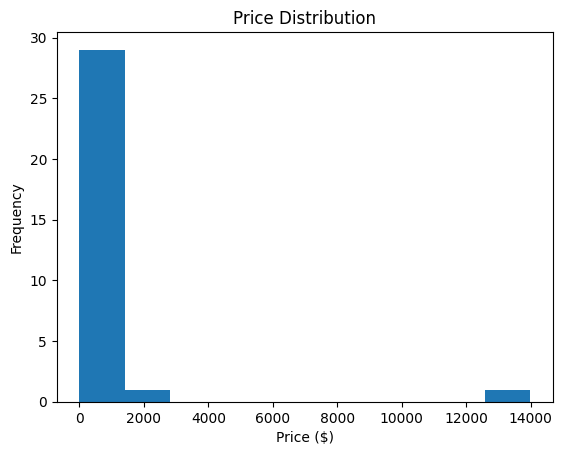

type
other       12
watch        8
ring         5
necklace     3
bracelet     3
Name: count, dtype: int64


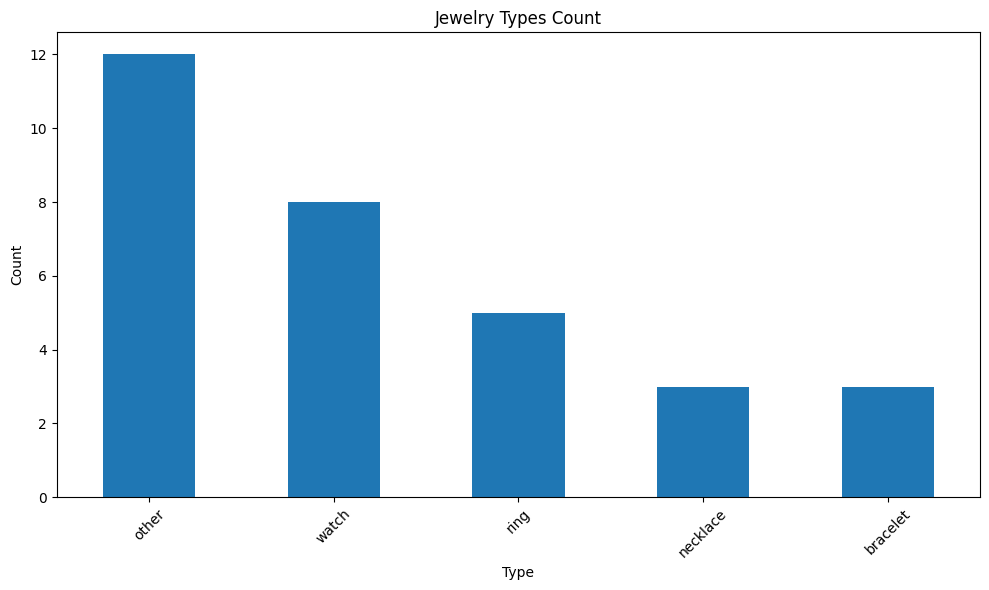

          count         mean          std   min    25%    50%     75%      max
type                                                                          
bracelet    3.0    26.666667    20.207259  15.0  15.00   15.0   32.50     50.0
necklace    3.0    58.666667    45.883911   6.0  43.00   80.0   85.00     90.0
other      12.0  1444.750000  4024.965028   5.0  17.50   37.5  182.50  13995.0
ring        5.0    80.200000   125.340337   0.0   1.00   50.0   50.00    300.0
watch       8.0   115.000000    37.032804  50.0  93.75  125.0  146.25    150.0


<Figure size 1200x600 with 0 Axes>

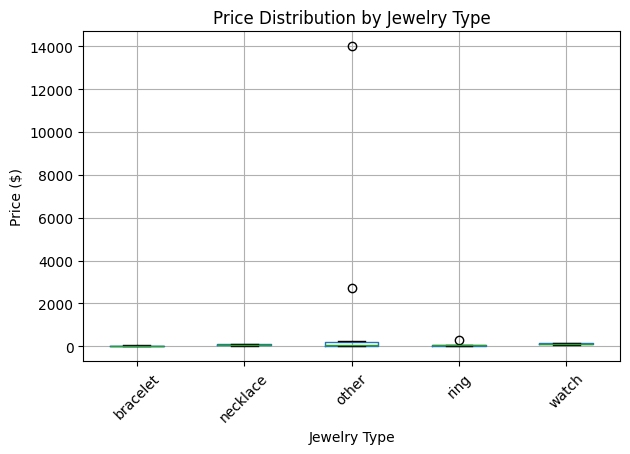

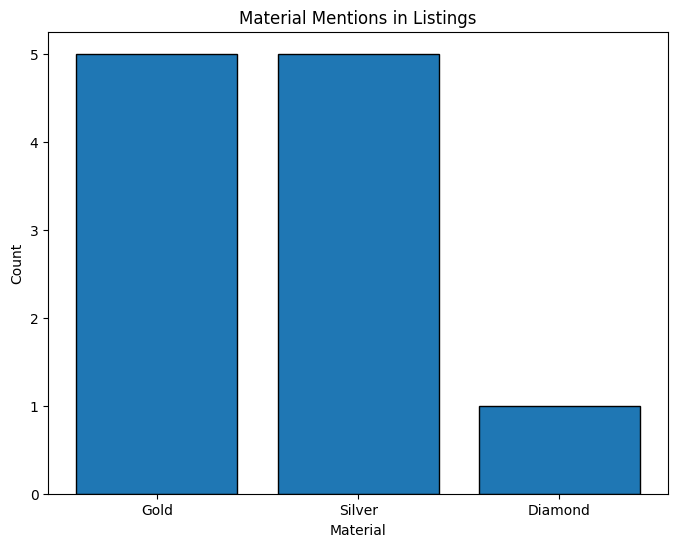

In [121]:
# EDA for price:
print(df['price'].describe())
df['price'].hist(grid=False)
plt.title('Price Distribution')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# EDA for jewelry types:
print(df['type'].value_counts())
plt.figure(figsize=(10, 6))
df['type'].value_counts().plot(kind='bar')
plt.title('Jewelry Types Count')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Price by jewelry type:
print(df.groupby('type')['price'].describe())
plt.figure(figsize=(12, 6))
df.boxplot(column='price', by='type')
plt.title('Price Distribution by Jewelry Type')
plt.suptitle('') 
plt.xlabel('Jewelry Type')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# EDA for materials:
material_counts = {
    'Gold': df['has_gold'].sum(),
    'Silver': df['has_silver'].sum(),
    'Diamond': df['has_diamond'].sum()
}
plt.figure(figsize=(8, 6))
plt.bar(material_counts.keys(), material_counts.values(), edgecolor='black')
plt.title('Material Mentions in Listings')
plt.xlabel('Material')
plt.ylabel('Count')
plt.show()

In [122]:
# Price by type:
df.loc[:,['price','type']].groupby('type').describe()

price                                                               
         count         mean          std   min    25%    50%     75%      max
type                                                                         
bracelet   3.0    26.666667    20.207259  15.0  15.00   15.0   32.50     50.0
necklace   3.0    58.666667    45.883911   6.0  43.00   80.0   85.00     90.0
other     12.0  1444.750000  4024.965028   5.0  17.50   37.5  182.50  13995.0
ring       5.0    80.200000   125.340337   0.0   1.00   50.0   50.00    300.0
watch      8.0   115.000000    37.032804  50.0  93.75  125.0  146.25    150.0

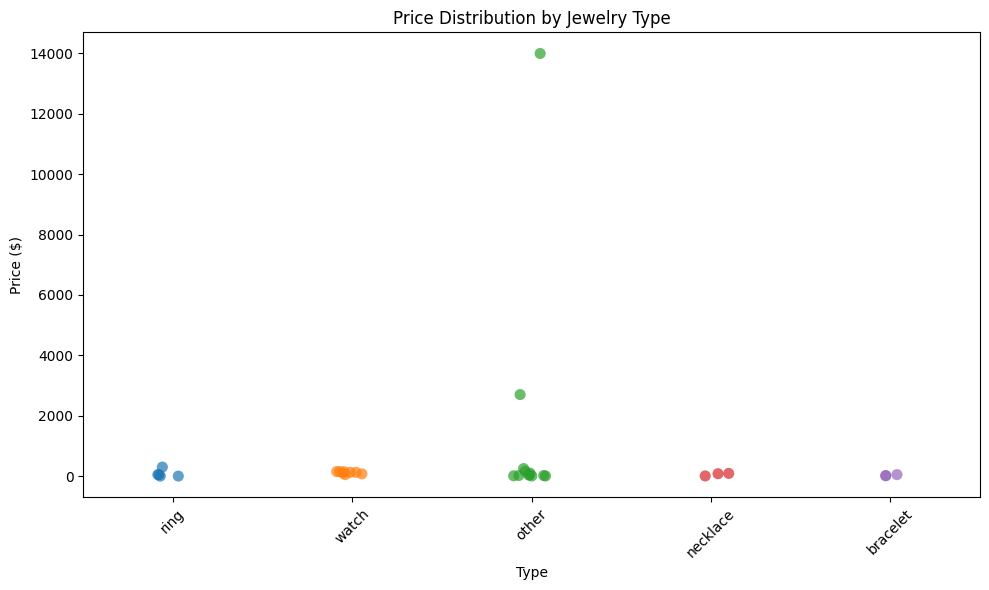

In [123]:
# Strip plot of price by type:
plt.figure(figsize=(10, 6))
ax = sns.stripplot(data=df, x='type', y='price', hue='type', alpha=0.7, jitter=True, s=8)
plt.xticks(rotation=45)
plt.title('Price Distribution by Jewelry Type')
plt.xlabel('Type')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

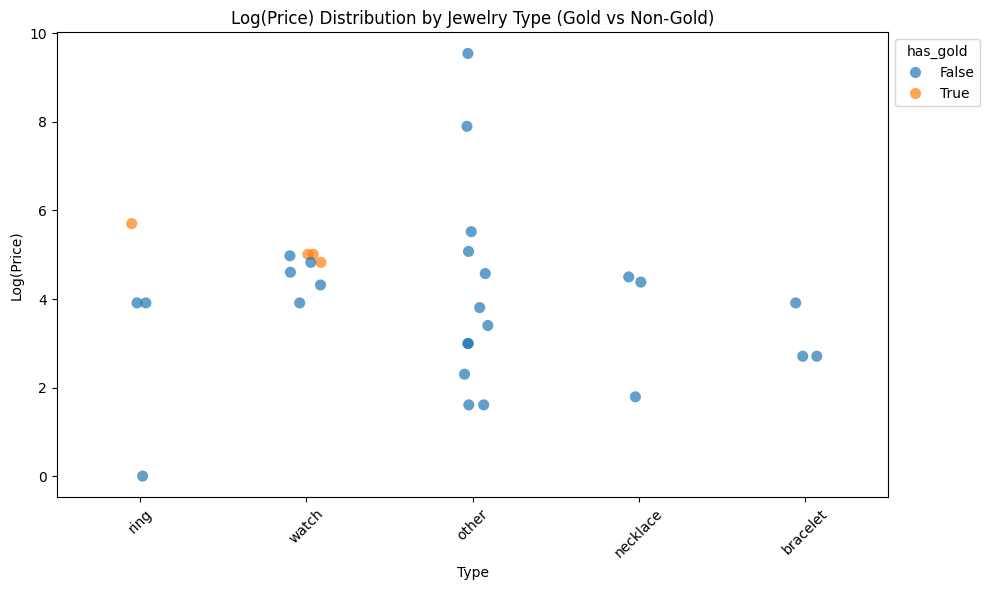

In [124]:
df['log_price'] = np.log(df[df['price'] > 0]['price'])

# Visualization: Price distribution by type
plt.figure(figsize=(10, 6))
ax = sns.stripplot(data=df, x='type', y='log_price', hue='has_gold', alpha=0.7, jitter=True, s=8)
plt.xticks(rotation=45)
plt.title('Log(Price) Distribution by Jewelry Type (Gold vs Non-Gold)')
plt.xlabel('Type')
plt.ylabel('Log(Price)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

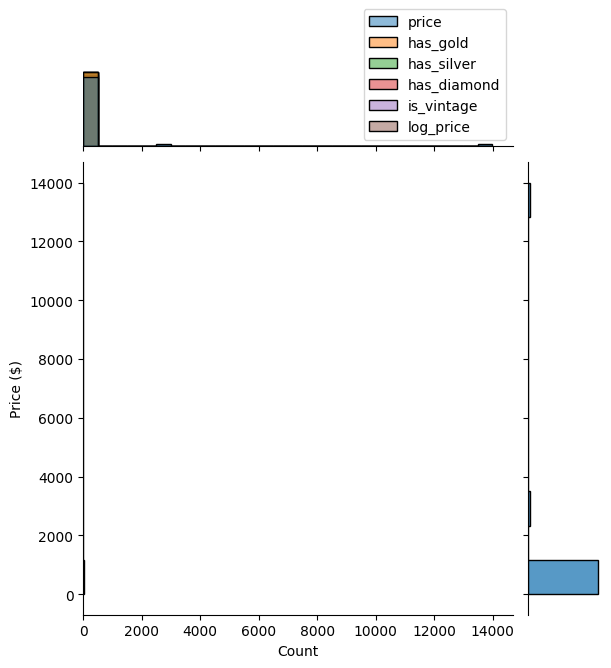

In [125]:
sns.jointplot(data=df, y='price', kind='hist')
plt.ylabel('Price ($)')
plt.show()


In [126]:
df.head()

,title,price,link,type,materials,condition,has_gold,has_silver,has_diamond,is_vintage,price_category,log_price
0,"> ladies ring - amethyst, diamonds & 10k gold,...",0,https://charlottesville.craigslist.org/jwl/d/c...,ring,"gold, diamond, vintage",vintage,True,False,True,True,free,NaN
1,vintage elgin ramona gold plated ladies watch ...,150,https://charlottesville.craigslist.org/jwl/d/c...,watch,"gold, vintage",vintage,True,False,False,True,mid-range,5.010635
2,vintage linda van der linde pink porcelain ear...,50,https://charlottesville.craigslist.org/jwl/d/c...,ring,vintage,vintage,False,False,False,True,budget,3.912023
3,silver rings,1,https://charlottesville.craigslist.org/jwl/d/g...,ring,silver,unknown,False,True,False,False,budget,0.000000
4,2002 tj 4.0 wrangler drivetrain 36 k original...,2700,https://charlottesville.craigslist.org/jwl/d/s...,other,unknown,unknown,False,False,False,False,luxury,7.901007


In [127]:
links = df['link']
date_data = []

print(f"Scraping dates for {len(links)} jewelry listings...")

for i, link in enumerate(links):
    try:
        time.sleep(random.randint(1, 2))
        
        raw = requests.get(link, headers=header)
        bsObj = soup(raw.content, 'html.parser')
        
        # Get posted date
        try:
            posted_time = bsObj.find('time', class_='date timeago')
            if posted_time:
                posted_date = posted_time.get('datetime')
                posted_text = posted_time.get_text().strip()
            else:
                # Fallback - look for "posted: X ago" text
                posted_text = bsObj.find('p', class_='postinginfo').get_text()
                posted_date = None
        except:
            posted_date = None
            posted_text = 'unknown'
        
        # Get post ID
        try:
            post_id = bsObj.find('p', class_='postinginfo').get_text()
            post_id_match = re.search(r'post id: (\d+)', post_id)
            post_id = post_id_match.group(1) if post_id_match else 'unknown'
        except:
            post_id = 'unknown'
        
        record = {
            'link': link,
            'posted_date': posted_date,
            'posted_text': posted_text,
            'post_id': post_id
        }
        date_data.append(record)
        
        if (i + 1) % 5 == 0:
            print(f"Processed {i + 1}/{len(links)} listings...")
            
    except Exception as e:
        print(f"Error processing link {i}: {e}")
        date_data.append({
            'link': link,
            'posted_date': None,
            'posted_text': 'error',
            'post_id': 'error'
        })

print("Done!")

# Merge with existing data
date_df = pd.DataFrame(date_data)
df_with_dates = df.merge(date_df, on='link', how='left')

df_with_dates.to_csv('craigslist_cville_jewelry_with_dates.csv', index=False)
df_with_dates.head()


Scraping dates for 31 jewelry listings...
Processed 5/31 listings...
Processed 10/31 listings...
Processed 15/31 listings...
Processed 20/31 listings...
Processed 25/31 listings...
Processed 30/31 listings...
Done!


,title,price,link,type,materials,condition,has_gold,has_silver,has_diamond,is_vintage,price_category,log_price,posted_date,posted_text,post_id
0,"> ladies ring - amethyst, diamonds & 10k gold,...",0,https://charlottesville.craigslist.org/jwl/d/c...,ring,"gold, diamond, vintage",vintage,True,False,True,True,free,NaN,2025-08-22T23:52:55-0400,2025-08-22 23:52,unknown
1,vintage elgin ramona gold plated ladies watch ...,150,https://charlottesville.craigslist.org/jwl/d/c...,watch,"gold, vintage",vintage,True,False,False,True,mid-range,5.010635,2026-02-01T15:47:32-0500,2026-02-01 15:47,unknown
2,vintage linda van der linde pink porcelain ear...,50,https://charlottesville.craigslist.org/jwl/d/c...,ring,vintage,vintage,False,False,False,True,budget,3.912023,2025-12-19T13:46:08-0500,2025-12-19 13:46,unknown
3,silver rings,1,https://charlottesville.craigslist.org/jwl/d/g...,ring,silver,unknown,False,True,False,False,budget,0.000000,2026-02-03T07:02:22-0500,2026-02-03 07:02,unknown
4,2002 tj 4.0 wrangler drivetrain 36 k original...,2700,https://charlottesville.craigslist.org/jwl/d/s...,other,unknown,unknown,False,False,False,False,luxury,7.901007,2026-01-10T01:24:48-0500,2026-01-10 01:24,unknown


In [128]:
new_df = pd.DataFrame.from_dict(data)
new_df.head()

,title,price,link,type,materials,condition,has_gold,has_silver,has_diamond,is_vintage
0,"> ladies ring - amethyst, diamonds & 10k gold,...",$0,https://charlottesville.craigslist.org/jwl/d/c...,ring,"gold, diamond, vintage",vintage,True,False,True,True
1,vintage elgin ramona gold plated ladies watch ...,$150,https://charlottesville.craigslist.org/jwl/d/c...,watch,"gold, vintage",vintage,True,False,False,True
2,vintage linda van der linde pink porcelain ear...,$50,https://charlottesville.craigslist.org/jwl/d/c...,ring,vintage,vintage,False,False,False,True
3,silver rings,$1,https://charlottesville.craigslist.org/jwl/d/g...,ring,silver,unknown,False,True,False,False
4,2002 tj 4.0 wrangler drivetrain 36 k original...,"$2,700",https://charlottesville.craigslist.org/jwl/d/s...,other,unknown,unknown,False,False,False,False


In [129]:
new_df.shape

(31, 10)

In [130]:
df = pd.concat([df,new_df],axis=1) # combine data frames
df.head()

,title,price,link,type,materials,condition,has_gold,has_silver,has_diamond,is_vintage,...,title,price,link,type,materials,condition,has_gold,has_silver,has_diamond,is_vintage
0,"> ladies ring - amethyst, diamonds & 10k gold,...",0,https://charlottesville.craigslist.org/jwl/d/c...,ring,"gold, diamond, vintage",vintage,True,False,True,True,...,"> ladies ring - amethyst, diamonds & 10k gold,...",$0,https://charlottesville.craigslist.org/jwl/d/c...,ring,"gold, diamond, vintage",vintage,True,False,True,True
1,vintage elgin ramona gold plated ladies watch ...,150,https://charlottesville.craigslist.org/jwl/d/c...,watch,"gold, vintage",vintage,True,False,False,True,...,vintage elgin ramona gold plated ladies watch ...,$150,https://charlottesville.craigslist.org/jwl/d/c...,watch,"gold, vintage",vintage,True,False,False,True
2,vintage linda van der linde pink porcelain ear...,50,https://charlottesville.craigslist.org/jwl/d/c...,ring,vintage,vintage,False,False,False,True,...,vintage linda van der linde pink porcelain ear...,$50,https://charlottesville.craigslist.org/jwl/d/c...,ring,vintage,vintage,False,False,False,True
3,silver rings,1,https://charlottesville.craigslist.org/jwl/d/g...,ring,silver,unknown,False,True,False,False,...,silver rings,$1,https://charlottesville.craigslist.org/jwl/d/g...,ring,silver,unknown,False,True,False,False
4,2002 tj 4.0 wrangler drivetrain 36 k original...,2700,https://charlottesville.craigslist.org/jwl/d/s...,other,unknown,unknown,False,False,False,False,...,2002 tj 4.0 wrangler drivetrain 36 k original...,"$2,700",https://charlottesville.craigslist.org/jwl/d/s...,other,unknown,unknown,False,False,False,False


In [131]:
df.dtypes

title                  str
price                int64
link                   str
type                   str
materials              str
condition              str
has_gold              bool
has_silver            bool
has_diamond           bool
is_vintage            bool
price_category    category
log_price          float64
title                  str
price                  str
link                   str
type                   str
materials              str
condition              str
has_gold              bool
has_silver            bool
has_diamond           bool
is_vintage            bool
dtype: object

**Outcome:**

For this lab, I collected data from Craigslist jewelry listings in the Charlottesville area. Rather than focusing on used cars, I chose jewelry because it allowed me to explore how materials, vintage labeling, and item type relate to price. From each listing, I extracted the title, price, posting date, and link. I also added additional features, like the materials (gold, silver, diamond), if it was vintage or not, item type (ring, watch, bracelet, etc.), and price categories (budget, mid-range, luxury).

After wrangling, I was able to get 31 listings with prices ranging from $0 to over $10,000. Most of the items fell into the budget price range, with a heavily right-skewed price distribution. The listings that had gold or diamonds tended to be more expensive, while silver or unspecified materials were generally cheaper. A majority of posts were marked as “unknown” condition, which suggests that the material of the jewelry is not often posted in the listings.